# **1. Descripción del Problema**

**Problema:** Clasificación binaria de reseñas de Amazon como positivas (1) o negativas (0)

**Objetivo:** Predecir el sentimiento a partir del texto de la reseña

# **2. Carga y Exploración Inicial (EDA)**

In [28]:
import kagglehub

# Descarga la última versión del dataset de Kaggle
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

# Imprime la ruta donde se encuentran descargados los archivos del dataset
print("Path to dataset files:", path)

Path to dataset files: C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7


In [29]:
# Como Kagglehub descarga los archivos en una carpeta oculta dentro del caché de usuario, 
# vamos a copiarlos a una ubicación más accesible para su análisis.

import shutil
import os

# Ruta donde Kagglehub guarda los archivos descargados
origen_path = r"C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7"

# Ruta destino donde queremos copiar los archivos
destino_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Copiar todos los archivos del origen al destino
for archivo in os.listdir(origen_path):
    ruta_origen = os.path.join(origen_path, archivo)
    ruta_destino = os.path.join(destino_path, archivo)
    if os.path.isfile(ruta_origen):
        shutil.copy2(ruta_origen, ruta_destino)

print("Archivos copiados exitosamente a:", destino_path)


Archivos copiados exitosamente a: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset


In [43]:
# Vamos a explorar el contenido de los archivos .bz2 descargados y listar algunas líneas de ejemplo.

import bz2
import os

# Iterar por los archivos .bz2
for archivo in os.listdir(destino_path):
    if archivo.endswith(".bz2"):
        ruta_completa = os.path.join(destino_path, archivo)
        print(f"\n=== Contenido de {archivo} ===")
        
        # Abrir el archivo y leer algunas líneas
        with bz2.open(ruta_completa, "rt", encoding="utf-8") as f:
            for i, linea in enumerate(f):
                print(linea.strip())
                if i >= 4:  # Mostrar solo las primeras 5 líneas
                    break


=== Contenido de test.ft.txt.bz2 ===
__label__2 Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"
__label__2 One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especial

In [ ]:
# Ahora procedemos con el análisis de datos utilizando pandas, numpy, matplotlib, seaborn, y nltk.

import bz2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Descargar recursos NLTK 
nltk.download('stopwords') # Se usa para eliminar palabras comunes como "y", "el", "de", etc.
nltk.download('punkt') # Se usa para tokenizar el texto en palabras como "Hola, ¿cómo estás?" -> ["Hola", ",", "¿", "cómo", "estás", "?"]

# Función para leer y parsear archivos .bz2
def parse_bz2_file(file_path, sample_size=50000):

    # Listas para almacenar los datos
    reviews = []
    labels = []
    
    # En el ejercicio inicial se usó un enfoque incorrecto para abrir archivos bz2, por lo tanto, con el try-except se maneja cualquier error.
    try:
        print(f"Intentando abrir: {file_path}")
        print("Archivo abierto correctamente.")
        
        # Abrir el archivo bz2 correctamente
        with bz2.open(file_path, 'rt', encoding='utf-8') as file:
            for i, line in enumerate(file):
                if i >= sample_size:
                    break
                    
                # Mostrar progreso cada 10,000 líneas para monitorear el avance
                if i % 10000 == 0 and i > 0:
                    print(f"Procesadas {i} líneas...")
                
                # Parsear la línea (formato: __label__1 o __label__2)
                if line.startswith('__label__1'):
                    labels.append(1)  # Positivo
                    reviews.append(line[len('__label__1 '):].strip())
                elif line.startswith('__label__2'):
                    labels.append(0)  # Negativo
                    reviews.append(line[len('__label__2 '):].strip())
        
        # Confirmar el número de reseñas procesadas
        print(f"Procesamiento completado: {len(reviews)} reseñas")
        print("\n")
        
    except Exception as e:
        print(f"Error: {e}")
        return None
    
    # Crear DataFrame
    return pd.DataFrame({'review_text': reviews, 'sentiment': labels})

# Mensaje para indicar que se están cargando los datos y que el proceso hasta ahora es correcto
print("\n")
print("=== CARGANDO DATOS CON RUTAS CORRECTAS ===")
print("\n")

# Definir la ruta base donde se encuentran los archivos
base_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Rutas completas a los archivos de entrenamiento y prueba
train_path = os.path.join(base_path, "train.ft.txt.bz2")
test_path = os.path.join(base_path, "test.ft.txt.bz2")

# Cargar dataset de entrenamiento
df_train = parse_bz2_file(train_path, sample_size=50000)

# Cargar dataset de prueba  
df_test = parse_bz2_file(test_path, sample_size=10000)

# Verificar que se cargó correctamente el dataset de entrenamiento
if df_train is not None:
    print(f"Distribución de sentimientos en train:")
    print(df_train['sentiment'].value_counts())
else:
    print("Error cargando train")

# Verificar que se cargó correctamente el dataset de prueba
if df_test is not None:
    print(f"Distribución de sentimientos en test:")
    print(df_test['sentiment'].value_counts())
else:
    print("Error cargando test")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!




=== CARGANDO DATOS CON RUTAS CORRECTAS ===


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\train.ft.txt.bz2
Archivo abierto correctamente.
Procesadas 10000 líneas...
Procesadas 20000 líneas...
Procesadas 30000 líneas...
Procesadas 40000 líneas...
Procesamiento completado: 50000 reseñas


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\test.ft.txt.bz2
Archivo abierto correctamente.
Procesamiento completado: 10000 reseñas


Distribución de sentimientos en train:
sentiment
0    25506
1    24494
Name: count, dtype: int64
Distribución de sentimientos en test:
sentiment
0    5125
1    4875
Name: count, dtype: int64


=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===
Dimensiones del dataset de entrenamiento: (50000, 3)


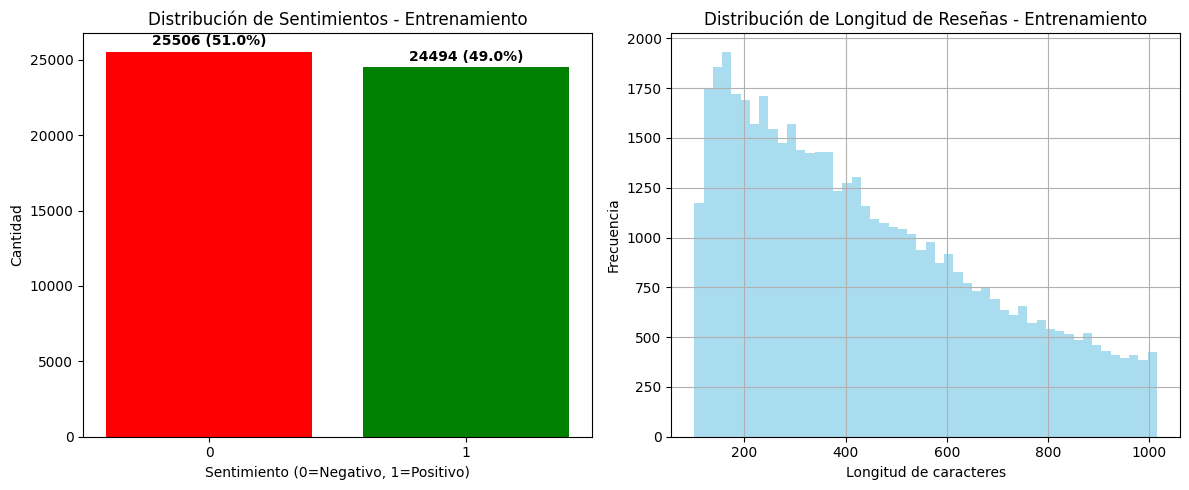

Longitud promedio de reseñas (Entrenamiento): 441.02 caracteres
Longitud máxima (Entrenamiento): 1015 caracteres
Longitud mínima (Entrenamiento): 101 caracteres


=== ANÁLISIS DEL DATASET DE PRUEBA ===
Dimensiones del dataset de prueba: (10000, 3)


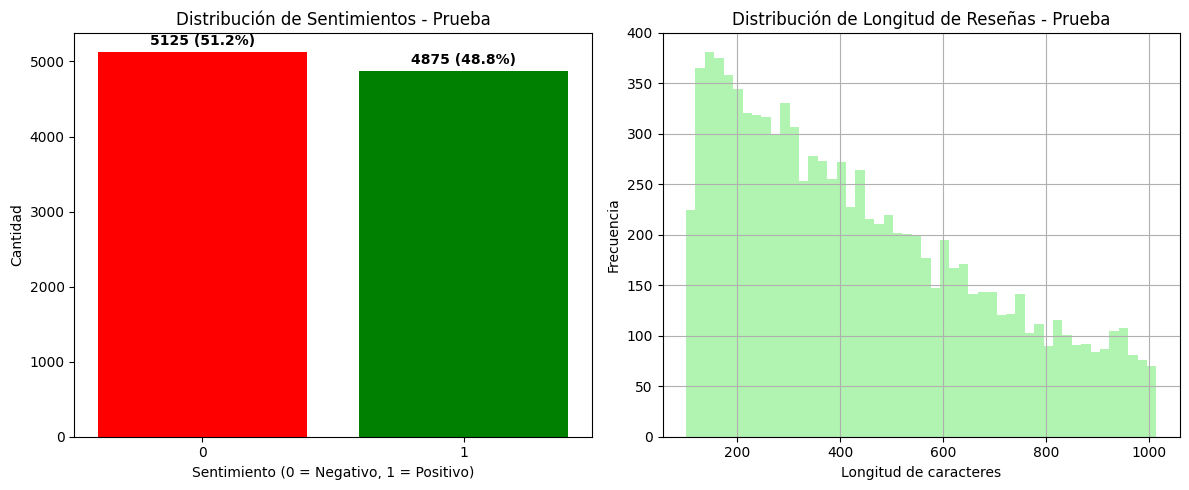

Longitud promedio de reseñas (Prueba): 440.06 caracteres
Longitud máxima (Prueba): 1015 caracteres
Longitud mínima (Prueba): 101 caracteres


In [48]:
import matplotlib.pyplot as plt

# Vamos a analizar ambos datasets por separado: entrenamiento y prueba.

# Análisis del dataset de entrenamiento
print("=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===")
print(f"Dimensiones del dataset de entrenamiento: {df_train.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Entrenamiento)
plt.subplot(1, 2, 1)
sent_counts_train = df_train['sentiment'].value_counts().sort_index()
sent_percent_train = (sent_counts_train / len(df_train)) * 100

bars_train = plt.bar(sent_counts_train.index.astype(str), sent_counts_train.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Entrenamiento')
plt.xlabel('Sentimiento (0=Negativo, 1=Positivo)')
plt.ylabel('Cantidad')

# Etiquetas de cantidad y porcentaje
for i, bar in enumerate(bars_train):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_train) * 0.005),
        f"{sent_counts_train.iloc[i]} ({sent_percent_train.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Entrenamiento)
df_train['review_length'] = df_train['review_text'].str.len()
plt.subplot(1, 2, 2)
df_train['review_length'].hist(bins=50, alpha=0.7, color='skyblue')
plt.title('Distribución de Longitud de Reseñas - Entrenamiento')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Entrenamiento)
print(f"Longitud promedio de reseñas (Entrenamiento): {df_train['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Entrenamiento): {df_train['review_length'].max()} caracteres")
print(f"Longitud mínima (Entrenamiento): {df_train['review_length'].min()} caracteres")
print("\n")

# --- Análisis del dataset de prueba ---
print("=== ANÁLISIS DEL DATASET DE PRUEBA ===")
print(f"Dimensiones del dataset de prueba: {df_test.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Prueba)
plt.subplot(1, 2, 1)
sent_counts_test = df_test['sentiment'].value_counts().sort_index()
sent_percent_test = (sent_counts_test / len(df_test)) * 100

bars_test = plt.bar(sent_counts_test.index.astype(str), sent_counts_test.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Prueba')
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad')

# Etiquetas con cantidad y porcentaje
for i, bar in enumerate(bars_test):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_test) * 0.005),
        f"{sent_counts_test.iloc[i]} ({sent_percent_test.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Prueba)
df_test['review_length'] = df_test['review_text'].str.len()
plt.subplot(1, 2, 2)
df_test['review_length'].hist(bins=50, alpha=0.7, color='lightgreen')
plt.title('Distribución de Longitud de Reseñas - Prueba')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Prueba)
print(f"Longitud promedio de reseñas (Prueba): {df_test['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Prueba): {df_test['review_length'].max()} caracteres")
print(f"Longitud mínima (Prueba): {df_test['review_length'].min()} caracteres")


In [49]:
# Los porcentajes y conteos de sentimientos, así como las estadísticas de longitud de reseñas, muestran un comportamiento muy similar 
# entre los datasets de entrenamiento y prueba. Por lo tanto, no se observan diferencias significativas que puedan afectar el rendimiento del modelo.

# **3. Preprocesamiento de Texto (Optimizado)**

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer

# Unimos ambos datasets para el preprocesamiento ya que la información de ambos datasets es similar en cantidades y distribución.
df = pd.concat([df_train, df_test])

# Preprocesamiento de texto optimizado 
def preprocess_text_optimized(text):
    
    # Verificar si el texto es una cadena
    if not isinstance(text, str):
        return ""
    
    # Convertir a minúsculas para estandarizar
    text = text.lower()
    
    # Eliminar caracteres especiales y números, mantener palabras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenización simple para mejorar velocidad
    tokens = text.split()
    
    # Eliminar stopwords y aplicar stemming
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

# Aplicar preprocesamiento a una muestra si el dataset es muy grande
print("Preprocesando texto...")
df_sample = df.sample(10000, random_state=42)  # Muestra para desarrollo
df_sample['cleaned_review'] = df_sample['review_text'].apply(preprocess_text_optimized)

# Verificar resultados del preprocesamiento
print("\nEEjemplo de texto original:")
print(df_sample['review_text'].iloc[0][:200])
print("\nEjemplo de texto preprocesado:")
print(df_sample['cleaned_review'].iloc[0])



Preprocesando texto...

EEjemplo de texto original:
Order cancelled: Never received item, vendor not very responsive or helpful via feedback - did not reply for days. Ended up cancelling order due to long delay between order date and vendor never provi

Ejemplo de texto preprocesado:
order cancel never receiv item vendor respons help via feedback repli day end cancel order due long delay order date vendor never provid proof deliveri order cancel still receiv confirm acknowledg vendor cancel end disput charg order supplier
